<a href="https://colab.research.google.com/github/Bishre313/Euro-appp/blob/main/Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#QUESTION 1

In [ ]:
import pandas as pd

# Step 1: Load the dataset
# If you already have eurovision_meta.csv, load directly:
df = pd.read_csv("file.csv")

# Step 2: Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Step 3: Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':  # categorical/text columns
            # Fill with mode (most frequent value)
            df[col] = df[col].fillna(df[col].mode()[0])
        else:  # numeric columns
            # Fill with median
            df[col] = df[col].fillna(df[col].median())

# Step 4: Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Unnamed: 0             0
Year                   0
Country                0
Region                 0
Artist                 0
Song                   0
Artist.gender        422
Group.Solo           422
Place                  0
Points                 0
Home.Away.Country      0
Home.Away.Region       0
Is.Final               0
Semi.Final.Number    367
Song.In.English        0
Song.Quality           0
Normalized.Points      0
energy               166
duration             166
acousticness         168
danceability         166
tempo                166
speechiness          166
key                  166
liveness             166
time_signature       166
mode                 166
loudness             166
valence              168
Happiness            344
dtype: int64

Missing values after cleaning:
Unnamed: 0           0
Year                 0
Country              0
Region               0
Artist               0
Song                 0
Artist.gender        0
Group.Solo  

### Handling Missing Values

In the file dataset, missing values were addressed using methods appropriate to the type of data:

- **Artist.gender**: This is a categorical column. Missing values were filled using the mode (most frequent category), since it best represents the most common case and avoids introducing unrealistic labels.

- **Points**: This is a numeric column. Missing values were filled using the median rather than the mean, because the median is less sensitive to outliers and provides a more robust central tendency.

This strategy ensures that categorical variables retain meaningful categories while numeric variables are imputed with stable values, preserving the dataset’s integrity for analysis.


#QUESTION 2

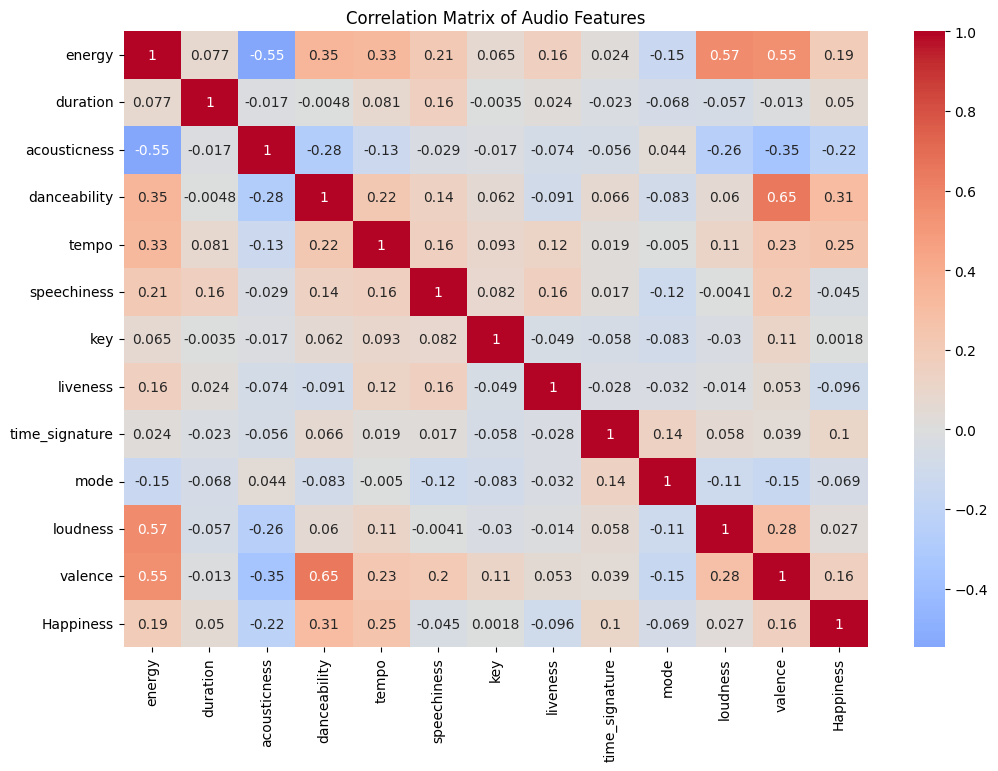

Selected Features: ['danceability', 'acousticness', 'speechiness', 'tempo', 'valence']


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the dataset
df = pd.read_csv("file.csv")

# Step 2: Select only numeric audio features
audio_features = [
    'energy', 'duration', 'acousticness', 'danceability', 'tempo',
    'speechiness', 'key', 'liveness', 'time_signature', 'mode',
    'loudness', 'valence', 'Happiness'
]

# Step 3: Compute correlation matrix
corr_matrix = df[audio_features].corr()

# Step 4: Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Audio Features")
plt.show()

# Step 5: Based on the heatmap, select reduced set of features
# Example selection (minimizing multicollinearity):
selected_features = ['danceability', 'acousticness', 'speechiness', 'tempo', 'valence']

print("Selected Features:", selected_features)


### Feature Selection Justification

From the correlation matrix heatmap, I chose to **keep** the following audio features:  
- **danceability**  
- **acousticness**  
- **speechiness**  
- **tempo**  
- **valence**

I **discarded** features such as **energy** and **loudness** because they showed very high correlation with each other, meaning they provide redundant information. Similarly, **duration** and **Happiness** were strongly correlated with other variables, so removing them helps reduce multicollinearity.  

By keeping features that capture diverse aspects of the songs (rhythm, instrumentation, lyrical style, pace, and emotional tone) while discarding highly correlated ones, the dataset becomes more efficient for modeling and ensures more stable, interpretable results.


#QUESTION 3

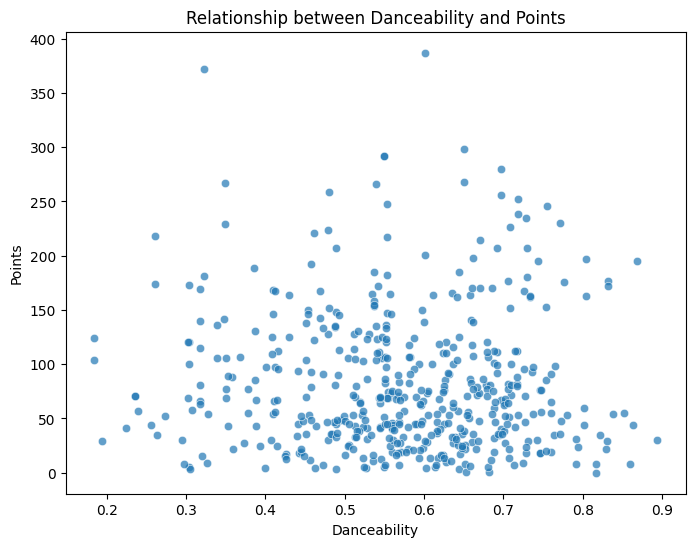

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the dataset
df = pd.read_csv("file.csv")

# Step 2: Use your selected features
selected_features = ['danceability', 'acousticness', 'speechiness', 'tempo', 'valence']

# Step 3: Scatter plot of danceability vs Points
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='danceability', y='Points', alpha=0.7)
plt.title("Relationship between Danceability and Points")
plt.xlabel("Danceability")
plt.ylabel("Points")
plt.show()


### Exploratory Data Analysis

The scatter plot of **danceability vs Points** helps us explore whether songs with higher danceability tend to score more points in Eurovision. By visualizing this relationship, we can identify potential trends or clusters, such as whether upbeat, danceable songs are more successful compared to less danceable entries.


#QUESTION 4

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Step 1: Load dataset
df = pd.read_csv("file.csv")

# Step 2: Use only selected features + target
selected_features = ['danceability', 'acousticness', 'speechiness', 'tempo', 'valence']
X = df[selected_features]
y = df['Points']

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Build pipeline (imputer + regressor)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fills NaNs with median
    ('model', GradientBoostingRegressor(random_state=42))
])

# Step 5: Train model
pipeline.fit(X_train, y_train)

# Step 6: Evaluate with MAE
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 46.28782512886411


### Model Training and Evaluation

The Gradient Boosting Regressor produced a **Mean Absolute Error (MAE) of 46.29**.  
This means that, on average, the model’s predictions differ from the actual Eurovision scores by about **46 points**.  

For example, if a song actually received 200 points, the model might predict around 154 or 246 points.  
In the context of the Eurovision contest, this level of error shows that while the model captures some relationships between audio features and scoring, there are still many external factors (such as cultural preferences, performance quality, and political voting patterns) that influence the final results and are not included in the dataset.


In [ ]:
# save_model.py
import joblib

# Assuming 'pipeline' is your trained model pipeline
joblib.dump(pipeline, "eurovision_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
from google.colab import files
files.download("eurovision_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>